<a href="https://colab.research.google.com/github/sachinthadilshann/pytorch_course_by_DanielBourke/blob/main/04_pytorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Importing PyTorch and setting up device-agnostic code

In [1]:
import torch
from torch import nn

torch.__version__

'2.11.0+cu128'

In [2]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')


Using device: cuda


## 1.0 Getting Data

In [3]:
import requests
import zipfile
from pathlib import Path

data_path = Path('data/')
image_path = data_path / 'pizza_steak_sushi'

if image_path.is_dir():
    print(f'{image_path} directory exists.')
else:
    print(f'Did not find {image_path} directory, creating one...')
    image_path.mkdir(parents=True, exist_ok=True)

#Download
with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print('Downloading pizza, steak, sushi data...')
    f.write(request.content)

#unzip

with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
  print("Unzipping pizza,steak and sushi data")
  zip_ref.extractall(image_path)







data/pizza_steak_sushi directory exists.
Unzipping pizza,steak and sushi data


In [4]:
import os

def walk_through_dirr(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} dieections and {len(filenames)} images in '{dirpath}'")

In [5]:
walk_through_dirr(image_path)

There are 2 dieections and 0 images in 'data/pizza_steak_sushi'
There are 3 dieections and 0 images in 'data/pizza_steak_sushi/train'
There are 0 dieections and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 dieections and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 dieections and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 3 dieections and 0 images in 'data/pizza_steak_sushi/test'
There are 0 dieections and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 dieections and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 dieections and 31 images in 'data/pizza_steak_sushi/test/sushi'


In [6]:
#setup train and test paths

train_dir = image_path / 'train'
test_dir = image_path / 'test'



###2.1 Visualize an image

data/pizza_steak_sushi/train/pizza/12301.jpg
pizza
Random image path: data/pizza_steak_sushi/train/pizza/12301.jpg
Image class: pizza
Image height: 512
Image width: 384


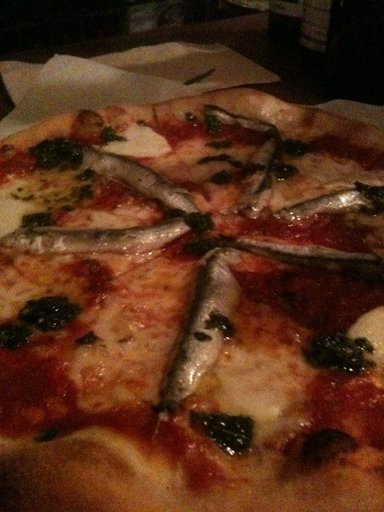

In [7]:
import random
from PIL import Image

image_path_list  = list(image_path.glob("*/*/*.jpg"))


random_image_path = random.choice(image_path_list)
print(random_image_path)


image_class = random_image_path.parent.stem
print(image_class)

img = Image.open(random_image_path)
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(383.5), np.float64(511.5), np.float64(-0.5))

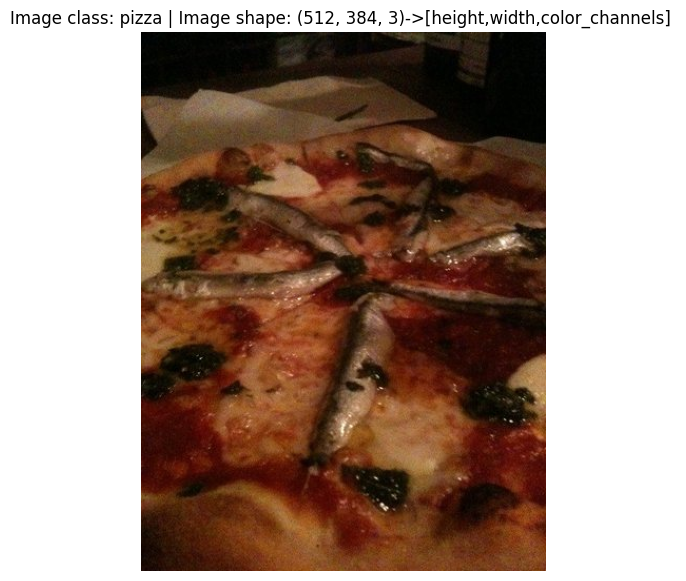

In [8]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}->[height,width,color_channels] ")
plt.axis(False)


##3. Transforming Data

###3.1 Transforming data with torchvision.transforms

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [10]:

data_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                                     transforms.RandomHorizontalFlip(p=0.5),
                                     transforms.ToTensor()])

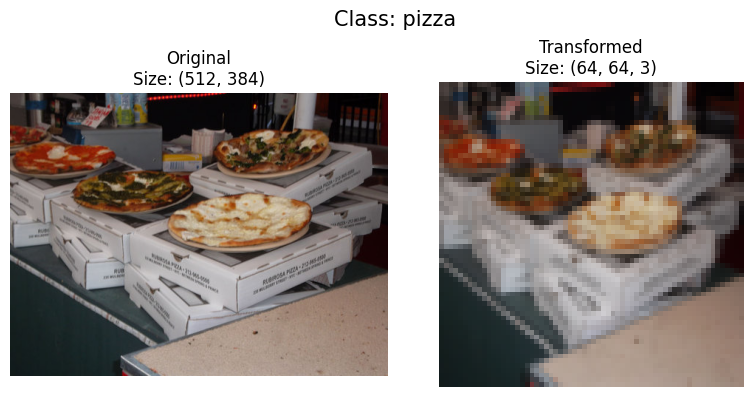

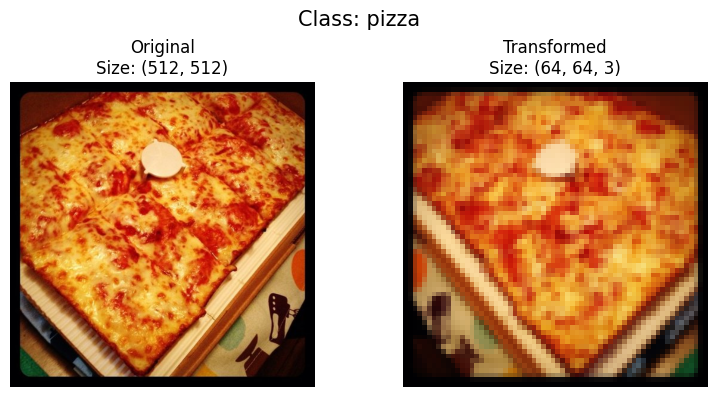

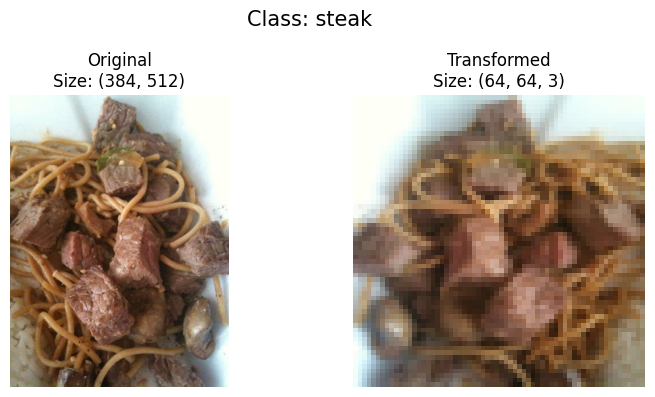

In [11]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_transform_images(image_path, transform, n=3, seed=42):
    random.seed(seed)
    random_image_paths = random.sample(image_path, k=n)

    for img_path in random_image_paths:
        with Image.open(img_path) as f:
            fig, ax = plt.subplots(1, 2, figsize=(8, 4))

            # Original
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis("off")

            # Transformed
            transformed_image = transform(f)
            transformed_image = (
                transformed_image.permute(1, 2, 0)
                .clamp(0, 1)
                .numpy()
            )

            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {img_path.parent.stem}", fontsize=15)
            plt.tight_layout()
            plt.show()

plot_transform_images(image_path_list,
                      data_transform,
                      n=3,
                      seed=42)


##4. Option 1: Loading Image Data Using [ImageFolder](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder)

In [12]:
from  torchvision import datasets, transforms

train_data  =  datasets.ImageFolder(root=train_dir,
                                    transform=data_transform,
                                    target_transform=None,
                                    )

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform,
                                 target_transform=None)


In [13]:
train_data

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [14]:
test_data

Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [15]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [16]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [17]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [18]:
len(train_data), len(test_data)

(225, 75)

In [19]:
train_data.samples[:5]

[('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1033251.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1044789.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1089334.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1105700.jpg', 0)]

In [20]:
train_data[0]

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

In [21]:
img,label = train_data[0][0],train_data[0][1]
img,label,class_names[label]

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

In [22]:
#class_names[label]

In [23]:
img,label = train_data[0][0],train_data[0][1]
print(f"Image shape: {img.shape}")
print(f"Label: {label}, Class: {class_names[label]}")
print(f"image datatype: {img.dtype}")
print(f"label datatype: {type(label)}")

Image shape: torch.Size([3, 64, 64])
Label: 0, Class: pizza
image datatype: torch.float32
label datatype: <class 'int'>


Original shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Image permute shape: torch.Size([64, 64, 3]) -> [height, width, color_channels]


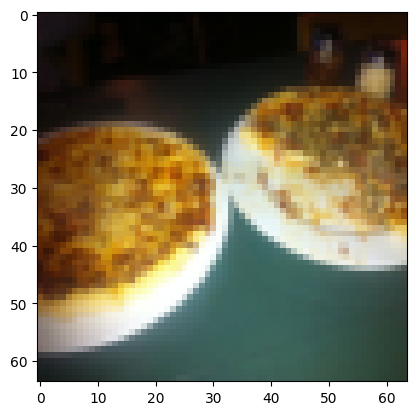

In [24]:
import matplotlib.pyplot as plt

img_permute = img.permute(1,2,0)
plt.imshow(img_permute)

print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permute.shape} -> [height, width, color_channels]")



##4.1 Turn loaded images into DataLoader's

In [25]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size = BATCH_SIZE,
                              num_workers = 1,
                              shuffle = True)


test_dataloader = DataLoader(dataset=test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)

train_dataloader,test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7b9fec2289e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7b9fec3da180>)

In [26]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [27]:
img,lable = next(iter(train_dataloader))
print(f"Image shape {img.shape}  -> [batch_size,color_channels_height,width]")



Image shape torch.Size([32, 3, 64, 64])  -> [batch_size,color_channels_height,width]


## 5 Option : Loading Images Data with a Custom dataset


In [28]:
import os
import pathlib
import torch
from torch.utils.data import Dataset
from typing import Tuple,Dict,List
from PIL import Image

In [29]:
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

In [30]:
#setup parth for target dir

targ_dir = train_dir
print(f"Target directory: {targ_dir}")

class_names_found = sorted([entry.name for entry in list(os.scandir(targ_dir))])

class_names_found

Target directory: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [31]:
list(os.scandir(targ_dir))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [32]:

def find_classes(dir:str) -> Tuple[List[str],Dict[str,int]]:
  classes = sorted(entry.name for entry in os.scandir(dir)  if entry.is_dir())

  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {dir}.")

  class_to_idx = {cls_name:idx for idx,cls_name in enumerate(class_names)}



  return classes,class_to_idx

In [33]:
find_classes(targ_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a Custom 'Dataset' to replicate 'ImageFolder'

In [34]:

from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):

  def __init__(self,
               target_dir:str,
               transforms=None) -> None:

    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))

    self.transforms = transforms

    self.classes,self.class_to_idx = find_classes(target_dir)

  def load_image(self,index:int) -> Image.Image:
    image_path = self.paths[index]
    return Image.open(image_path)


  def __len__(self) -> int:
    return len(self.paths)

  def __getitem__(self,index:int) -> Tuple[torch.Tensor,int]:
    img = self.load_image(index)
    class_names = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_names]

    if self.transforms:
      return self.transforms(img),class_idx
    else:
      return img,class_idx



In [35]:
img,lable = train_data[0]
img,lable

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

In [36]:

#create transform

train_transforms = transforms.Compose([transforms.Resize(size=(64,64)),
                                     transforms.RandomHorizontalFlip(p=0.5),
                                     transforms.ToTensor()])

test_transforms = transforms.Compose([transforms.Resize(size=(64,64)),
                                     transforms.ToTensor()])

In [37]:
#test out ImageFolderCustom


train_data_custom = ImageFolderCustom(target_dir=train_dir,
                                      transforms=train_transforms)
test_data_custom = ImageFolderCustom(target_dir=test_dir,
                                     transforms=test_transforms)

In [38]:
train_data_custom,test_data_custom


(<__main__.ImageFolderCustom at 0x7b9febf67080>,
 <__main__.ImageFolderCustom at 0x7b9febf50320>)

In [39]:
len(train_data_custom),len(test_data_custom)

(225, 225)

In [40]:
len(test_data),len(test_data)

(75, 75)

In [41]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [42]:
print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

False
True
True


### 5.3 Create random function for display image

In [43]:
# 1. Take in a Dataset as well as a list of class names
def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):

    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    # 3. Set random seed
    if seed:
        random.seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

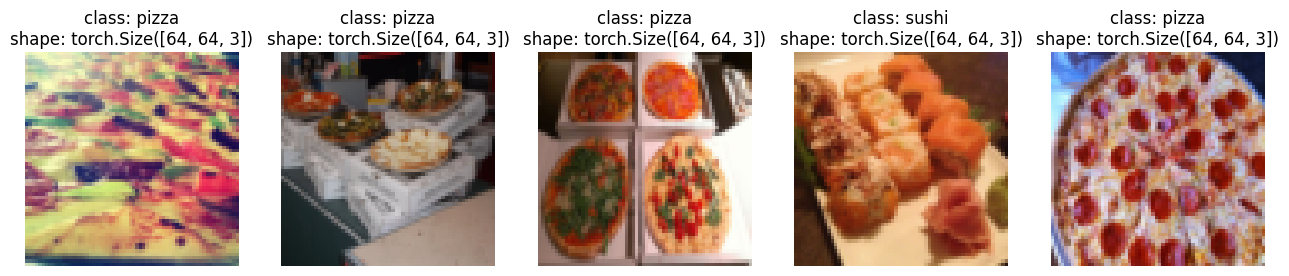

In [44]:
display_random_images(dataset=train_data_custom,
                      classes=train_data_custom.classes,
                      n=5,
                      display_shape=True)

For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.


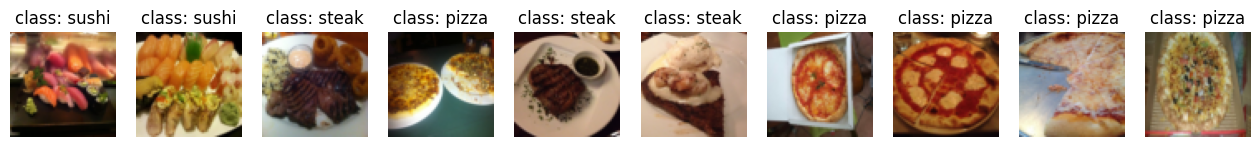

In [45]:
#Display random images from the ImageFolderCustom Dataset


display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=None)

### 5.4 Trun custom loaded images into DataLoder's

In [46]:
from torch.utils.data import DataLoader

BATCH_SIZE = 12


train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     num_workers=0,
                                     shuffle=True)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    num_workers=0,
                                    shuffle=False)

In [47]:
train_dataloader_custom,test_data_custom

(<torch.utils.data.dataloader.DataLoader at 0x7b9febe6ef00>,
 <__main__.ImageFolderCustom at 0x7b9febf50320>)

In [48]:
img_custom, label_custom = next(iter(train_dataloader_custom))


print(f"Image shape: {img_custom.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label_custom.shape}")

Image shape: torch.Size([12, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([12])


#6. Other forms of transforms (data augmentation)


In [49]:
 from torchvision import transforms

 train_transform = transforms.Compose([
     transforms.Resize(size=(224,224)),
     transforms.TrivialAugmentWide(num_magnitude_bins=31),
     transforms.ToTensor(),
 ])

 test_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                      transforms.ToTensor]
                                     )

In [50]:
image_path

PosixPath('data/pizza_steak_sushi')

In [51]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:5]

[PosixPath('data/pizza_steak_sushi/train/pizza/741883.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2026009.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2451169.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2493954.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2285942.jpg')]

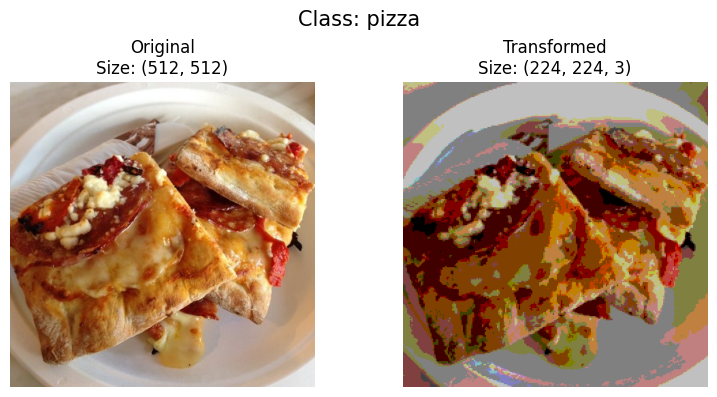

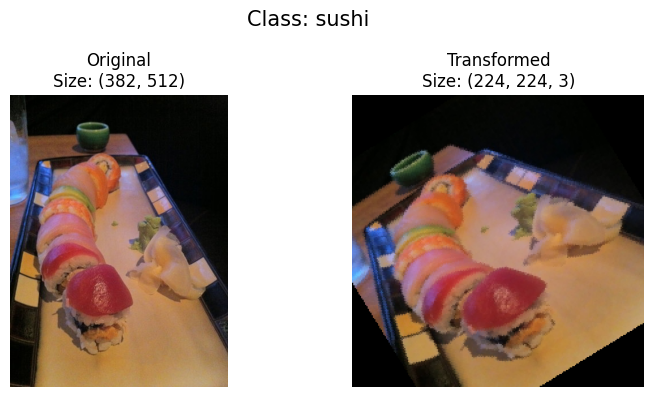

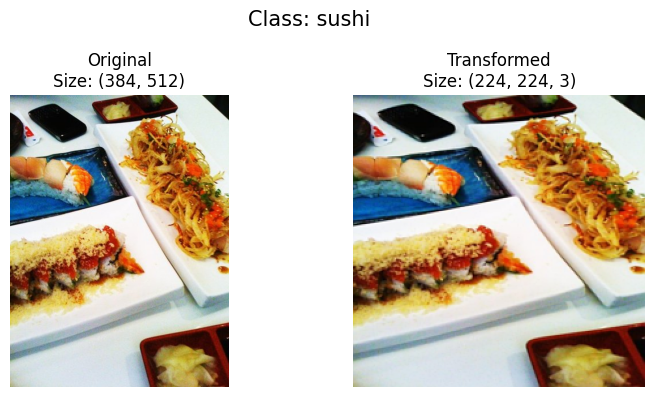

In [52]:
plot_transform_images(
    image_path=image_path_list,
    transform=train_transform,
    n=3,
    seed=None
)

## 7. Model 0  TinyVGG without

### 7.1 Creating transforms and loading data from model 0

In [53]:
simple_transform = transforms.Compose([transforms.Resize(size=(64,64)),
                                       transforms.ToTensor()])

In [54]:
from torchvision import datasets

train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform,
                                         target_transform=None)

test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform,
                                        target_transform=None)



import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WOKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WOKERS,
                                     shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WOKERS,
                                    shuffle=False)


In [55]:
NUM_WOKERS

2

### 7.2 TinyVGG model Class

In [56]:
class TinyVGG(nn.Module):
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int) -> None:

    super().__init__()

    self.conv_block_1 = nn.Sequential(
      nn.Conv2d(in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0),

      nn.ReLU(),

      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=0),
      nn.ReLU(),

      nn.MaxPool2d(2)
      )

    self.conv_block_2 = nn.Sequential(

      nn.Conv2d(hidden_units,hidden_units,3,1),

      nn.ReLU(),

      nn.Conv2d(hidden_units,hidden_units,3,1),
      nn.ReLU(),

      nn.MaxPool2d(2)
      )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13,
                 out_features=output_shape)
    )

  def forward(self,x:torch.Tensor):

      x = self.conv_block_1(x)
      x = self.conv_block_2(x)
      x = self.classifier(x)

      return x

In [57]:
  torch.manual_seed(42)

  model_0 = TinyVGG(
      input_shape=3,
      hidden_units=10,
      output_shape=len(train_data.classes)
      ).to(device)

  model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### 7.3 Try a forward pass on a single image (to test the model)

In [58]:
image_batch,label_batch = next(iter(train_dataloader_simple))

image_batch.shape,label_batch.shape




(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [59]:
#model_0(image_batch).to(device)

###7.4 Use torchinfo to get an idea of the shapes going through our model

In [60]:
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
summary(model_0, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

##7.5 Create train and test loop function

In [61]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer
):

    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)

        # Forward pass
        y_pred = model(X)

        # Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # Optimizer
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        y_pred_class = torch.argmax(
            torch.softmax(y_pred, dim=1),
            dim=1
        )

        train_acc += (
            (y_pred_class == y).sum().item()
            / len(y_pred)
        )

    # Average loss and accuracy
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [62]:
def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module
):

    model.eval()

    test_loss = 0
    test_acc = 0

    with torch.inference_mode():

        for batch, (X, y) in enumerate(dataloader):

            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred_logits = model(X)

            # Calculate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)

            test_acc += (
                (test_pred_labels == y).sum().item()
                / len(test_pred_labels)
            )

    # Average loss and accuracy
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc

###7.6 Creating a train()  function function to combine train_step() and test_step()

In [63]:
from tqdm.auto import tqdm


def train(model,
          train_dataloader,
          test_dataloader,
          optimizer,
          loss_fn,
          epochs):

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):

        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn
        )

        print(
            f"Epoch: {epoch+1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Test loss: {test_loss:.4f} | "
            f"Test acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

### 7.6 Train and evaluate model_0

In [64]:
NUM_EPOCHS = 10

#recrate an instance of TinyVGG

model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)
                  ).to(device)

model_0 = torch.compile(model_0)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)


from timeit import default_timer as timer
start_time = timer()

model_0_result = train(model=model_0,
                      train_dataloader=train_dataloader_simple,
                      test_dataloader=test_dataloader_simple,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS)


end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1/10 | Train loss: 1.0993 | Train acc: 0.4180 | Test loss: 1.1006 | Test acc: 0.1979
Epoch: 2/10 | Train loss: 1.1046 | Train acc: 0.2930 | Test loss: 1.1154 | Test acc: 0.1979
Epoch: 3/10 | Train loss: 1.0987 | Train acc: 0.2930 | Test loss: 1.1010 | Test acc: 0.1979
Epoch: 4/10 | Train loss: 1.0901 | Train acc: 0.3008 | Test loss: 1.0937 | Test acc: 0.1979
Epoch: 5/10 | Train loss: 1.0901 | Train acc: 0.3359 | Test loss: 1.0840 | Test acc: 0.2699
Epoch: 6/10 | Train loss: 1.0452 | Train acc: 0.5117 | Test loss: 1.0773 | Test acc: 0.3106
Epoch: 7/10 | Train loss: 1.0210 | Train acc: 0.4688 | Test loss: 1.0941 | Test acc: 0.2396
Epoch: 8/10 | Train loss: 1.0063 | Train acc: 0.4102 | Test loss: 1.0122 | Test acc: 0.5436
Epoch: 9/10 | Train loss: 0.9580 | Train acc: 0.5469 | Test loss: 0.9858 | Test acc: 0.4536
Epoch: 10/10 | Train loss: 0.9206 | Train acc: 0.5469 | Test loss: 0.9822 | Test acc: 0.4744
Total training time: 15.702 seconds


In [65]:
model_0_result

{'train_loss': [1.0993236899375916,
  1.1045995205640793,
  1.0986532270908356,
  1.0900530964136124,
  1.090135097503662,
  1.045231208205223,
  1.0209843292832375,
  1.0062600150704384,
  0.9580024406313896,
  0.92062047123909],
 'train_acc': [0.41796875,
  0.29296875,
  0.29296875,
  0.30078125,
  0.3359375,
  0.51171875,
  0.46875,
  0.41015625,
  0.546875,
  0.546875],
 'test_loss': [1.1006299257278442,
  1.1153948307037354,
  1.1010425090789795,
  1.0936998923619587,
  1.0840295950571697,
  1.0773048003514607,
  1.0940605401992798,
  1.012210766474406,
  0.9857998689015707,
  0.9822225173314413],
 'test_acc': [0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666,
  0.19791666666666666,
  0.26988636363636365,
  0.3106060606060606,
  0.23958333333333334,
  0.5435606060606061,
  0.45359848484848486,
  0.4744318181818182]}

### 7.8 Plot the loss curves of Model_0

In [66]:
model_0_result.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [67]:
def plot_loss_curves(results:Dict[str, List[float]]):

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


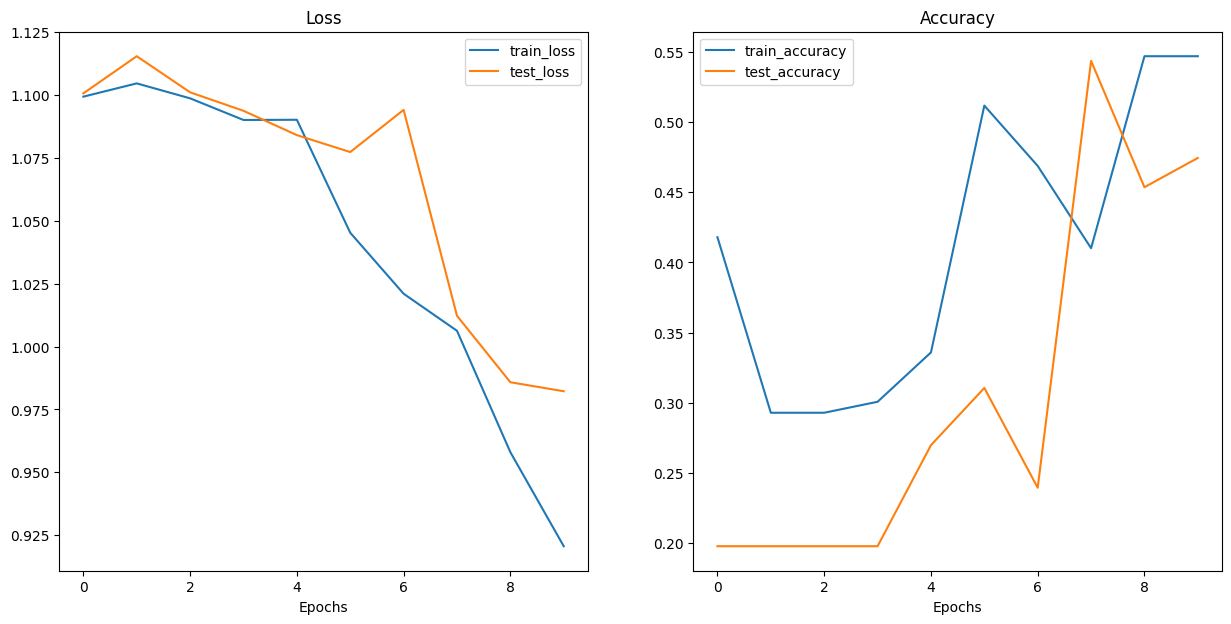

In [68]:
plot_loss_curves(model_0_result)

##. Model 1: TinyVGG with data Augmentations


###9.1 Create transform with data augmentation

In [69]:
from torchvision import transforms

train_transforms_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])



###9.2 Create train and test Datasets and Dataloder with data Augmentations

In [70]:
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                            transform = train_transforms_trivial,
                                            )

test_data_simple = datasets.ImageFolder(root=test_dir,
                                       transform=test_transform_simple)

import os

BATCH_SIZE = 8
NUM_WORKERS = os.cpu_count()
EPOCHS = 10

train_dataLoader_augmented = DataLoader(dataset= train_data_augmented,
                                        batch_size = BATCH_SIZE,
                                        shuffle=True,
                                        num_workers= NUM_WORKERS)

test_dataLoder_simple = DataLoader(dataset=test_data_simple,
                                   batch_size = BATCH_SIZE,
                                   num_workers=NUM_WORKERS)

###9.3 train model 3

In [71]:
model_1 = TinyVGG(input_shape=3,
                  hidden_units = 10,
                  output_shape=len(train_data.classes)
                  ).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model_1_results = train(model_1,
                        train_dataLoader_augmented,
                        test_dataLoder_simple,
                        optimizer,
                        loss_fn,
                        EPOCHS
                        )

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1/10 | Train loss: 1.1064 | Train acc: 0.3276 | Test loss: 1.1007 | Test acc: 0.3125
Epoch: 2/10 | Train loss: 1.1029 | Train acc: 0.3362 | Test loss: 1.0976 | Test acc: 0.3125
Epoch: 3/10 | Train loss: 1.0971 | Train acc: 0.4397 | Test loss: 1.1040 | Test acc: 0.3250
Epoch: 4/10 | Train loss: 1.0801 | Train acc: 0.4612 | Test loss: 1.0793 | Test acc: 0.3250
Epoch: 5/10 | Train loss: 1.0517 | Train acc: 0.4957 | Test loss: 1.0701 | Test acc: 0.3000
Epoch: 6/10 | Train loss: 0.9880 | Train acc: 0.5129 | Test loss: 1.0011 | Test acc: 0.3875
Epoch: 7/10 | Train loss: 0.9844 | Train acc: 0.5216 | Test loss: 0.9852 | Test acc: 0.4208
Epoch: 8/10 | Train loss: 0.9833 | Train acc: 0.5216 | Test loss: 0.9877 | Test acc: 0.4792
Epoch: 9/10 | Train loss: 0.9232 | Train acc: 0.5474 | Test loss: 1.0384 | Test acc: 0.3750
Epoch: 10/10 | Train loss: 0.9374 | Train acc: 0.5517 | Test loss: 0.9964 | Test acc: 0.4458
Total training time: 11.684 seconds


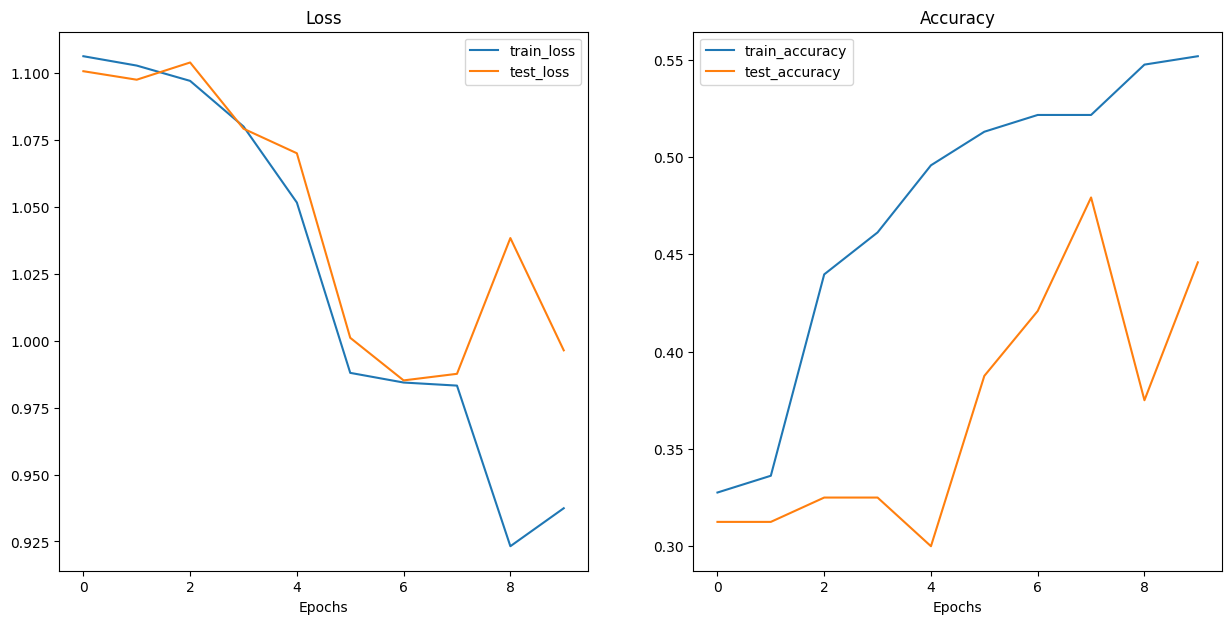

In [72]:
plot_loss_curves(model_1_results)

In [73]:

import pandas as pd
model_0_df = pd.DataFrame(model_0_result)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.099324,0.417969,1.100630,0.197917
1,1.104600,0.292969,1.115395,0.197917
2,1.098653,0.292969,1.101043,0.197917
3,1.090053,0.300781,1.093700,0.197917
4,1.090135,0.335938,1.084030,0.269886
5,1.045231,0.511719,1.077305,0.310606
6,1.020984,0.468750,1.094061,0.239583
7,1.006260,0.410156,1.012211,0.543561
8,0.958002,0.546875,0.985800,0.453598
9,0.920620,0.546875,0.982223,0.474432


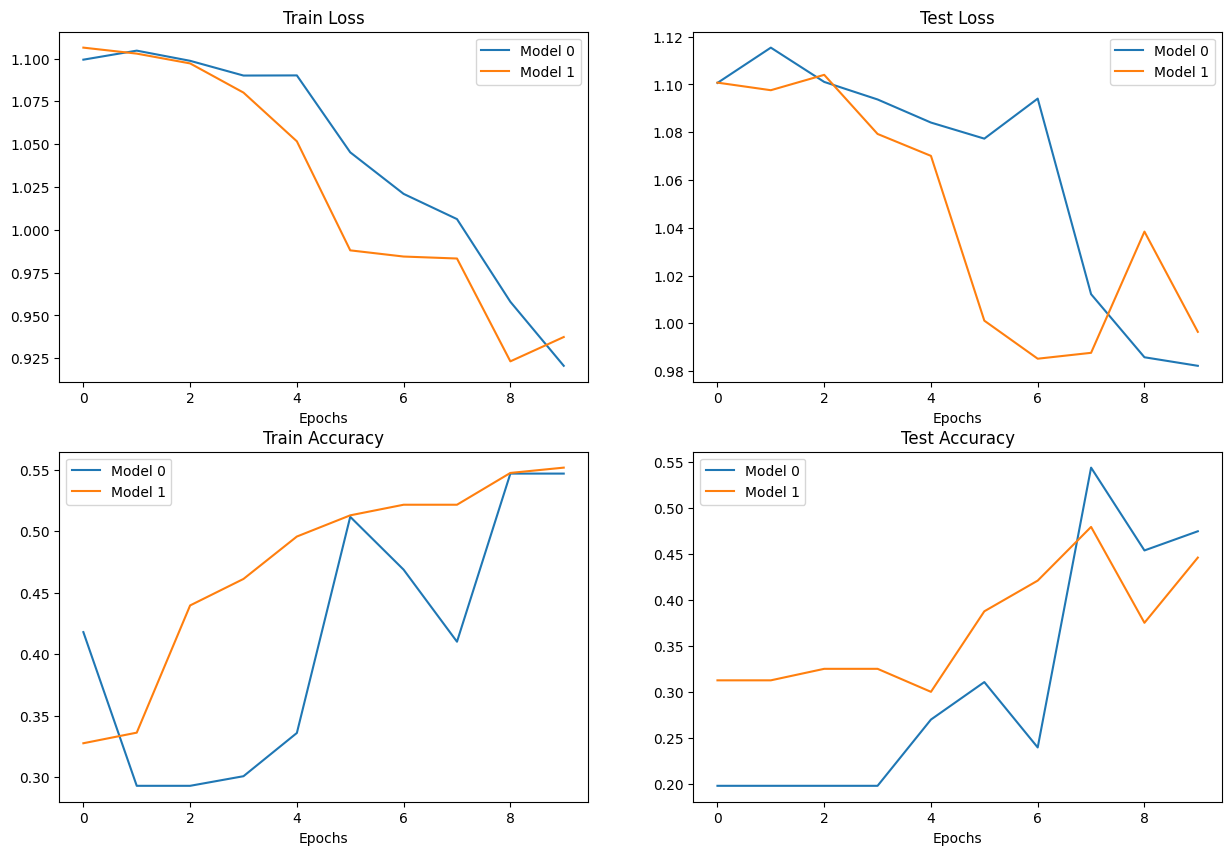

In [74]:
plt.figure(figsize=(15, 10))


epochs_0 = range(len(model_0_df))
epochs_1 = range(len(model_1_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs_0, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs_1, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs_0, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs_1, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs_0, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs_1, model_1_df["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs_0, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs_1, model_1_df["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();

##11. Making a prediction on a Custom image

In [75]:
import requests

custom_image_path = data_path/ "img_01.jpge"

if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    request = requests.get("https://raw.githubusercontent.com/sachinthadilshann/pytorch_course_by_DanielBourke/refs/heads/main/img_01.jpeg")
    print(f"Downloading {custom_image_path}.....")
    f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

data/img_01.jpge already exists, skipping download.


###11.1 Loading in a custom image with PyTorch

In [76]:
import torchvision

custom_image_uint8 = torchvision.io.read_file(str(custom_image_path))
#custom_image_uint8

print(f"Custom image tensor:\n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor:
tensor([255, 216, 255,  ...,  63, 255, 217], dtype=torch.uint8)

Custom image shape: torch.Size([64968])

Custom image dtype: torch.uint8


###11.2 Predicting on custom images with a trained PyTorch model

In [77]:
model_1.eval()
with torch.inference_mode():
  custom_image_tensor = torchvision.io.decode_image(custom_image_uint8).to(device)


In [78]:
custom_image = torchvision.io.decode_image(custom_image_uint8).to(torch.float32) / 255.
custom_image

tensor([[[0.9373, 1.0000, 0.8824,  ..., 0.9176, 0.9176, 0.9137],
         [0.7176, 0.8627, 0.8471,  ..., 0.9176, 0.9176, 0.9137],
         [0.5843, 0.7333, 0.7647,  ..., 0.9176, 0.9176, 0.9137],
         ...,
         [0.8706, 0.8706, 0.8706,  ..., 0.9137, 0.8235, 0.8627],
         [0.9216, 0.9059, 0.8745,  ..., 0.9020, 0.8196, 0.8549],
         [0.8941, 0.8980, 0.9020,  ..., 0.9176, 0.8353, 0.8588]],

        [[0.6275, 0.7059, 0.5725,  ..., 0.9176, 0.9176, 0.9137],
         [0.4078, 0.5529, 0.5373,  ..., 0.9176, 0.9176, 0.9137],
         [0.2706, 0.4157, 0.4549,  ..., 0.9176, 0.9176, 0.9137],
         ...,
         [0.6588, 0.6627, 0.6706,  ..., 0.9137, 0.8235, 0.8627],
         [0.7137, 0.6980, 0.6745,  ..., 0.9020, 0.8196, 0.8549],
         [0.6824, 0.6902, 0.6980,  ..., 0.9176, 0.8353, 0.8588]],

        [[0.3569, 0.4431, 0.3137,  ..., 0.9176, 0.9176, 0.9137],
         [0.1373, 0.2902, 0.2784,  ..., 0.9176, 0.9176, 0.9137],
         [0.0000, 0.1569, 0.1961,  ..., 0.9176, 0.9176, 0.

In [79]:
custom_image.shape

torch.Size([3, 480, 638])

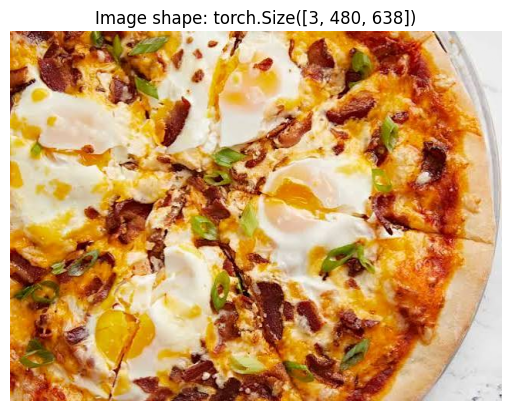

In [80]:

# Plot custom image
plt.imshow(custom_image.permute(1, 2, 0))
plt.title(f"Image shape: {custom_image.shape}")
plt.axis(False);

In [81]:
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)

# Print out original shape and new shape
print(f"Original shape: {custom_image.shape}")
print(f"New shape: {custom_image_transformed.shape}")

Original shape: torch.Size([3, 480, 638])
New shape: torch.Size([3, 64, 64])


In [82]:
def pred_img(model: torch.nn.Module,
             image_path:str,
             class_names:List[str]=None,
             transform=None,
             device=device):

  #load image

  # Read the image file as raw bytes
  image_uint8_bytes = torchvision.io.read_file(str(image_path))
  # Decode the raw bytes into a proper image tensor and normalize
  target_img = torchvision.io.decode_image(image_uint8_bytes).to(torch.float32) / 255.

  #transform data

  if transform:
    target_img = transform(target_img)


  model.to(device)

  model.eval()
  with torch.inference_mode():
    target_img = target_img.unsqueeze(0)

    target_image_pred = model(target_img.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

  plt.imshow(target_img.squeeze().permute(1, 2, 0))
  if class_names:
    title=f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max():.3f}"
  else:
    title=f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max():.3f}"

  plt.title(title)
  plt.axis(False)

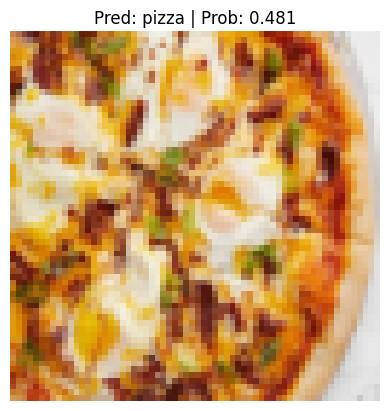

In [83]:
pred_img(model=model_0,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)

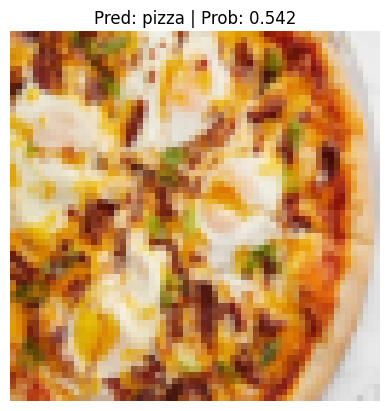

In [84]:
pred_img(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)